In [1]:
import pandas as pd
import glob
from pathlib import Path
# os.listdir('../../data/sefaz-sp/2026-03-05/')

# Funções

In [2]:
def lista_df(tipo,data='',uf='rn'):
    path_data = Path('../../data/')
    
    arquivos = path_data.rglob(f'sefaz-{uf}/**/*{tipo}*{data}*.parquet')
    arquivos = [str(a) for a in arquivos]
    arquivos.sort()
    
    print('Prossibilidades:')
    for arquivo in arquivos:
        print(arquivo)
    
    return arquivos

def apura_provas(df,uf='mt'):
    # Consolida Provas
    if uf == 'mt':
        df['p1'] = df[['por', 'rl', 'ghm', 'dt', 'efp', 'aud', 'est', 'nda', 'ing','pf',]].sum(axis=1)
        df['p2'] = df[['ti', 'lte', 'cgc', 'mf',]].sum(axis=1)
        
        df['p1_prc'] = df['p1']/(80)*100
        df['p2_prc'] = df['p2']/(80*2)*100
        df['total_prc'] = df['total']/(80+80*2)*100
        df['aprovado'] = (df['p1']>=60) & (df['p2']>=60)  & (df['total_prc']>=70) 

        df['vagas'] = df['posicao'] <= 21
        df['cr'] = df['posicao'] <= 6000
    elif uf == 'sp':
        # SP
        df['p1'] = df[['por', 'mf', 'rc', 'ing', 'agp', 'efp',]].sum(axis=1)
        df['p2'] = df[['dca', 'dt', 'lte', 'cg', 'aud',]].sum(axis=1)
        df['p3'] = df[['dta', 'lta', 'cac', 'fd',]].sum(axis=1)
        
        df['p1_prc'] = df['p1']/(100)*100
        df['p2_prc'] = df['p2']/(80)*100
        df['p3_prc'] = df['p3']/(8*20)*100
        df['total_prc'] = df['total']/(100+80*3)*100
        df['aprovado'] = (df['p1']>=50) & (df['p2']>=40) & (df['p3']>=80)  & (df['total']>=204)
        
        df['vagas'] = df['posicao'] <= 150
        df['cr'] = df['posicao'] <= 285

    return df
    

def last_df(tipo,data='',uf='rn'):
    arquivos = lista_df(tipo,data=data,uf=uf)
    arquivos.sort()
    df_nome = arquivos[-1]

    print('Carrega: {}:'.format(df_nome),end='')
    df = pd.read_parquet(df_nome)

    # Transforma valores em inteiros
    colunas_int = df.columns[2:]
    df[colunas_int] = df[colunas_int].astype(int)
    df['posicao'] = df['posicao'].str.replace('º','').str.replace('.','').astype(int)

    # Transforma Dados
    df = apura_provas(df,uf=uf)

    print(df.shape)
    print()

    return df

In [3]:
def media(df,col,posicao):
    return df[col].iloc[posicao-100:posicao].mean()

def comparacao_disciplina(df,disciplinas=[],pontos=[],pesos=None):

    if pesos is None:
        pesos = [1,]*len(disciplinas)
    
    pontuacao_total = sum([a * b for a, b in zip(pontos, pesos)])
    posicoes = [100,200,300,500]
    totais = {100:0,200:0,300:0,500:0}
    
    df_tabela = pd.DataFrame(columns=["Prova", "100°", "200°", "300°", "500°"])
    
    for n in range(0,len(disciplinas)):
        disciplina = disciplinas[n]
        pontuacao = pontos[n]
        peso = pesos[n]
        
        linha = [disciplina]
        for posicao in posicoes:
            linha.append(media(df,disciplina,posicao)/pontuacao/peso*100)
            totais[posicao] = totais[posicao] + media(df,disciplina,posicao)
    
        df_tabela.loc[df_tabela.shape[0]] = linha
    
            
    df_tabela.loc[df_tabela.shape[0]] = ['total'] + [v*100/pontuacao_total for k,v in totais.items()]
    
    return df_tabela.style.format(precision=2)

# Carrega DataFrames

In [26]:
datas = ['2026-03-16','2026-03-17','2026-03-18']
dict_df_mt = {}
for data in datas:
    dict_df_mt[data] = last_df('pontos',data=data,uf='mt')
    
df = last_df('pontos',uf='mt')

Prossibilidades:
../../data/sefaz-mt/2026-03-16/df_pontos_2026-03-16_17-58.parquet
Carrega: ../../data/sefaz-mt/2026-03-16/df_pontos_2026-03-16_17-58.parquet:(242, 25)

Prossibilidades:
../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_10-31.parquet
../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_15-35.parquet
../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_20-39.parquet
Carrega: ../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_20-39.parquet:(477, 25)

Prossibilidades:
../../data/sefaz-mt/2026-03-16/df_pontos_2026-03-16_17-58.parquet
../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_10-31.parquet
../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_15-35.parquet
../../data/sefaz-mt/2026-03-17/df_pontos_2026-03-17_20-39.parquet
../../data/sefaz-mt/2026-03-18/df_pontos_2026-03-18_11-14.parquet
Carrega: ../../data/sefaz-mt/2026-03-18/df_pontos_2026-03-18_11-14.parquet:(505, 25)



In [52]:
import datetime
datetime.datetime.now()

datetime.datetime(2026, 3, 18, 16, 9, 30, 380083)

In [27]:
df_provas = df[['posicao','usuario','p1','p2','total','p1_prc','p2_prc','total_prc']]

In [28]:
df_sp = last_df('pontos',uf='sp')

Prossibilidades:
../../data/sefaz-sp/2026-03-05/df_pontos_2026-03-05_14-12.parquet
../../data/sefaz-sp/2026-03-07/df_pontos_2026-03-07_11-05.parquet
../../data/sefaz-sp/2026-03-09/df_pontos_2026-03-09_11-38.parquet
../../data/sefaz-sp/2026-03-10/df_pontos_2026-03-10_13-19.parquet
../../data/sefaz-sp/2026-03-11/df_pontos_2026-03-11_11-04.parquet
../../data/sefaz-sp/2026-03-12/df_pontos_2026-03-12_19-21.parquet
../../data/sefaz-sp/2026-03-13/df_pontos_2026-03-13_09-03.parquet
../../data/sefaz-sp/2026-03-16/df_pontos_2026-03-16_17-49.parquet
../../data/sefaz-sp/2026-03-17/df_pontos_2026-03-17_12-10.parquet
Carrega: ../../data/sefaz-sp/2026-03-17/df_pontos_2026-03-17_12-10.parquet:(2291, 28)



# Análise

In [29]:
meu_resultado = df_provas[df_provas['usuario'] == 'cf_auditor'].reset_index(drop=True)
meu_resultado

,posicao,usuario,p1,p2,total,p1_prc,p2_prc,total_prc
0,44,cf_auditor,62,132,194,77.5,82.5,80.833333


#### Análise por Colocação

In [30]:
comparacao_disciplina(df,disciplinas=['p1','p2'],pontos=[100,80*2,80],pesos=[1,1,2])

,Prova,100°,200°,300°,500°
0,p1,63.65,58.30,53.37,33.13
1,p2,81.66,74.97,67.10,36.74
2,total,46.26,42.44,38.27,21.88


#### Análise por P1

In [31]:
comparacao_disciplina(
    df,
    disciplinas=['por', 'rl', 'ghm', 'dt', 'efp', 'aud', 'est', 'nda', 'ing','pf',],
    pontos=[10,10,10,15,5,10,7,8,3,2])

,Prova,100°,200°,300°,500°
0,por,82.70,75.10,72.70,48.60
1,rl,57.90,50.90,43.70,28.60
2,ghm,83.00,75.30,76.50,59.30
3,dt,82.53,75.33,65.60,35.00
4,efp,66.80,60.00,41.80,23.40
5,aud,92.80,89.90,86.80,57.60
6,est,84.00,71.43,60.86,29.00
7,nda,78.62,76.75,72.75,40.62
8,ing,86.33,75.00,69.67,39.00
9,pf,76.50,74.50,65.00,42.50


#### Análise por P2

In [32]:
comparacao_disciplina(df,disciplinas=['ti', 'lte', 'cgc', 'mf',],pontos=[45*2,15*2,10*2,10*2])

,Prova,100°,200°,300°,500°
0,ti,84.96,79.73,76.13,44.58
1,lte,66.13,58.80,45.53,24.27
2,cgc,90.10,83.10,73.90,33.10
3,mf,81.70,69.70,52.00,23.80
4,total,81.66,74.97,67.10,36.74


#### Aprovados

In [33]:
# df_sp
df_merge = df.merge(df_sp, on='usuario',how='left',suffixes=('_mt', '_sp'))[['usuario','posicao_mt','posicao_sp','aprovado_mt','vagas_sp','cr_sp']]
# df_merge[df_merge['vagas']
df_merge['vagas_sp'] = df_merge['vagas_sp'].fillna(False).astype(bool)
df_merge['cr_sp'] = df_merge['cr_sp'].fillna(False).astype(bool)
ranking_mt_sp = df_merge[
    (df_merge['aprovado_mt']) & 
    (~df_merge['vagas_sp'])
].head(60).reset_index(drop=True)

ranking_mt_sp_cr = df_merge[
    (df_merge['aprovado_mt']) & 
    (~df_merge['cr_sp'])
].head(60).reset_index(drop=True)

In [34]:
n_ranking = df.shape[0]
posicao_mt = df.loc[df['usuario'] == 'cf_auditor','posicao'].item()
posicao_mt_sp = ranking_mt_sp.reset_index().loc[ranking_mt_sp['usuario'] == 'cf_auditor','index'].item() +1
posicao_mt_sp_cr = ranking_mt_sp.reset_index().loc[ranking_mt_sp_cr['usuario'] == 'cf_auditor','index'].item() +1

aprovados = df[df['aprovado']].shape[0]
n_ranking_prev = 600

prev_ranking = posicao_mt * n_ranking_prev/n_ranking
prev_oficial = prev_ranking * 1.2

prev_chamada_sp = posicao_mt_sp * n_ranking_prev/n_ranking
prev_chamada_oficial_sp = prev_chamada_sp * 1.2

prev_chamada_sp_cr = posicao_mt_sp_cr * n_ranking_prev/n_ranking
prev_chamada_oficial_sp_cr = prev_chamada_sp_cr * 1.2

print('{}/{}/{} ({:.2f}) Ranking: {:.1f} Oficial: {:.1f} Chamada: {:.1f} [Vagas SP]'.format(
    posicao_mt,n_ranking,n_ranking_prev,posicao_mt/n_ranking*100,
    prev_ranking,prev_oficial,prev_chamada_oficial_sp))

# 396/600 Ranking: 54.5 Oficial: 65.5 Chamada: 43.6 [Vagas SP]
# 451/600 Ranking: 57.2 Oficial: 68.6 Chamada: 44.7 [Vagas SP]
# 44/477/600 (9.22) Ranking: 55.3 Oficial: 66.4 Chamada: 43.8 [Vagas SP]
# 44/505/600 (8.71) Ranking: 52.3 Oficial: 62.7 Chamada: 42.8 [Vagas SP]

print('{}/{}/{} ({:.2f}) Ranking: {:.1f} Oficial: {:.1f} Chamada: {:.1f} [Vagas SP+CR]'.format(
    posicao_mt,n_ranking,n_ranking_prev,posicao_mt/n_ranking*100,
    prev_ranking,prev_oficial,prev_chamada_oficial_sp_cr))

# 44/477/600 (9.22) Ranking: 55.3 Oficial: 66.4 Chamada: 34.7 [Vagas SP+CR]
# 44/505/600 (8.71) Ranking: 52.3 Oficial: 62.7 Chamada: 34.2 [Vagas SP+CR]

44/505/600 (8.71) Ranking: 52.3 Oficial: 62.7 Chamada: 42.8 [Vagas SP]
44/505/600 (8.71) Ranking: 52.3 Oficial: 62.7 Chamada: 34.2 [Vagas SP+CR]


In [40]:
ranking_mt_sp

,usuario,posicao_mt,posicao_sp,aprovado_mt,vagas_sp,cr_sp
0,gyarados,1,237.0,True,False,True
1,aveztruzqseduz,3,NaN,True,False,False
2,mts_21:22,4,NaN,True,False,False
3,m_do_ac,5,NaN,True,False,False
4,estudaqdasorte,7,331.0,True,False,False
5,flanel@ josué 1.9,9,NaN,True,False,False
6,mhcc,10,549.0,True,False,False
7,leop25,11,NaN,True,False,False
8,d de deus a de amor,15,NaN,True,False,False
9,jp_bittenc,17,NaN,True,False,False


In [42]:
pne = 912
negros = 3726
geral = 14604

pne/geral*100 , negros/geral*100

(6.244864420706656, 25.51355792933443)

In [50]:
prev_aprovados_ranking = df[df['aprovado']].shape[0]
prev_aprovados_oficial = df[df['aprovado']].shape[0]* n_ranking_prev/n_ranking

prev_aprovados_ranking, prev_aprovados_oficial

(122, 144.95049504950495)

# Análise Gráfica

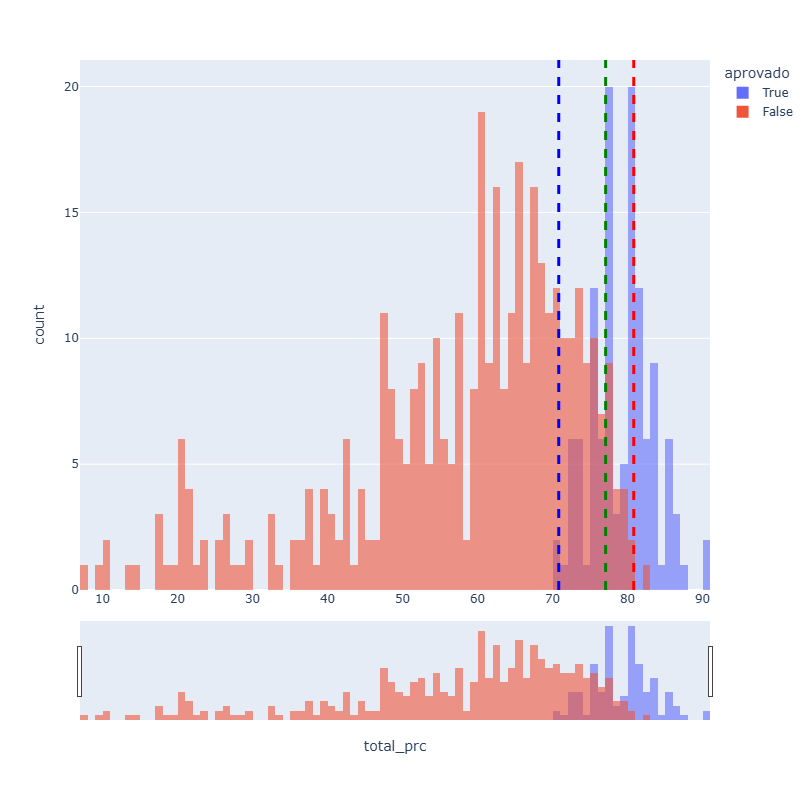

In [41]:
import plotly.express as px

df_fig = df
df_aprovado = df[df['aprovado']]

# df é o seu DataFrame do Pandas com os dados do ranking
fig = px.histogram(
    df_fig, 
    x="total_prc", 
    color="aprovado", 
    barmode='overlay',  # Este é o comando chave
    opacity=0.6,        # Opacidade para conseguir enxergar a sobreposição
    nbins=10)

# Se o total é 100 e você quer 50 bins, o size é 2
fig.update_traces(xbins=dict(
    size=1  # Força cada barra a ter largura 2
))

# Ativando o Range Slider no eixo X
fig.update_layout(
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="linear" # ou "date" para séries temporais
    )
)
fig.update_layout(
    height=800,  # Altura em pixels
    # width=1000   # Opcional: Largura em pixels
)
fig.add_vline(x=df['total_prc'].iloc[100], line_width=3, line_dash="dash", line_color="green")
fig.add_vline(x=df['total_prc'].iloc[200], line_width=3, line_dash="dash", line_color="blue")
# fig.add_vline(x=df['total_prc'].iloc[300], line_width=3, line_dash="dash", line_color="orange")
# fig.add_vline(x=df['total_prc'].iloc[500], line_width=3, line_dash="dash", line_color="yellow")
fig.add_vline(x=df[df_provas['usuario'] == 'cf_auditor']['total_prc'].iloc[0], line_width=3, line_dash="dash", line_color="red")


fig.show()

In [15]:
import plotly.express as px

df_fig = df[df['aprovado'] ]

# df é o seu DataFrame do Pandas com os dados do ranking
fig = px.line(df_fig, x="total_prc",y=df_fig.index)
# Se o total é 100 e você quer 50 bins, o size é 2
# fig.update_traces(xbins=dict(
#     size=1  # Força cada barra a ter largura 2
# ))

# # Ativando o Range Slider no eixo X
# fig.update_layout(
#     xaxis=dict(
#         rangeslider=dict(visible=True),
#         type="linear" # ou "date" para séries temporais
#     )
# )
# fig.update_layout(
#     height=800,  # Altura em pixels
#     # width=1000   # Opcional: Largura em pixels
# )
fig.add_vline(x=df_fig['total_prc'].iloc[100], line_width=3, line_dash="dash", line_color="green")
fig.add_vline(x=df_fig['total_prc'].iloc[200], line_width=3, line_dash="dash", line_color="blue")
fig.add_vline(x=df_fig['total_prc'].iloc[300], line_width=3, line_dash="dash", line_color="orange")
fig.add_vline(x=df_fig['total_prc'].iloc[500], line_width=3, line_dash="dash", line_color="yellow")
fig.add_vline(x=df[df_provas['usuario'] == 'cf_auditor']['total_prc'].iloc[0], line_width=3, line_dash="dash", line_color="red")


fig.show()

IndexError: single positional indexer is out-of-bounds